# MBH chain post-processing

Loads the Eryn HDF backend from `mbh_test_script_td_wave.py` and walks through the usual sanity checks: trace plots, acceptance fraction, autocorrelation, and a corner plot with injected values overlaid.

Chain dims for this run: `ntemps=2`, `nwalkers=2`, 11 sampled parameters in the order:
`mT, q, s1z, s2z, dist, phi_ref, cosinc, lam, sinbeta, psi, t_merger`.

With only `nsteps=20, thin_by=5` you have **4 saved samples per walker** — enough to confirm the pipeline runs, not enough for meaningful posteriors. Re-run the script with larger `nsteps` for real inference.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

from eryn.backends import HDFBackend

CHAIN_PATH = os.path.expanduser(
    "~/Documents/LISA/LISA_Sprint_2026/lisasprint26/lisa_sprint_2026/base_test_mbh_pe.h5"
)
backend = HDFBackend(CHAIN_PATH)
print(f"Loaded: {CHAIN_PATH}")

Loaded: /Users/oliverda/Documents/LISA/LISA_Sprint_2026/lisasprint26/lisa_sprint_2026/base_test_mbh_pe.h5


## 1. Chain shape and bookkeeping

In [2]:
chain = backend.get_chain()
log_like = backend.get_log_like()
log_prior = backend.get_log_prior()

mbh = chain["mbh"]
print("chain['mbh'] shape:", mbh.shape, "-> (nsteps_saved, ntemps, nwalkers, nleaves, ndim)")
print("log_like shape:    ", log_like.shape)
print("log_prior shape:   ", log_prior.shape)
print("iteration:         ", backend.iteration)

nsteps_saved, ntemps, nwalkers, nleaves, ndim = mbh.shape
print(f"\nUseful: {nsteps_saved} saved steps x {nwalkers} walkers = {nsteps_saved * nwalkers} cold-chain samples per parameter.")

chain['mbh'] shape: (2000, 2, 2, 1, 11) -> (nsteps_saved, ntemps, nwalkers, nleaves, ndim)
log_like shape:     (2000, 2, 2)
log_prior shape:    (2000, 2, 2)
iteration:          2000

Useful: 2000 saved steps x 2 walkers = 4000 cold-chain samples per parameter.


In [3]:
PARAM_NAMES = [
    "mT", "q", "s1z", "s2z", "dist",
    "phi_ref", "cosinc", "lam", "sinbeta", "psi", "t_merger",
]
assert len(PARAM_NAMES) == ndim, f"name list ({len(PARAM_NAMES)}) doesn't match ndim ({ndim})"

# Color scheme used throughout this notebook
INJ_COLOR = "purple"
REC_COLOR = "orange"

YRSID_SI = 31558149.763545603
INJECTED = {
    "mT":       1.5e6,
    "q":        0.5,
    "s1z":      0.9,
    "s2z":      0.8,
    "dist":     1.0e4,
    "phi_ref":  0.12984324823423,
    "cosinc":   np.cos(0.302001),
    "lam":      0.423234242,
    "sinbeta":  np.sin(0.88762349812312),
    "psi":      np.pi / 3.0,
    "t_merger": 1.2 * YRSID_SI - int(0.5 * YRSID_SI / 10.0) * 10.0,
}
truth = np.array([INJECTED[n] for n in PARAM_NAMES])

## 2. Acceptance fraction

Crude diagnostic: fraction of proposed moves that were accepted, per walker, on the cold chain. For StretchMove, you want this to be roughly 0.2-0.5. Values near 0 or 1 mean the proposal is poorly scaled.

In [4]:
try:
    af = backend.get_autocorr_time()
    print("autocorr times (per param, cold temp):")
    print(af)
except Exception as e:
    print("autocorr not yet usable:", e)

try:
    accept = backend.accepted  # shape (ntemps, nwalkers) cumulative
    print("\ncumulative acceptances (ntemps, nwalkers):\n", accept)
    print("fraction (vs iteration):", accept / max(backend.iteration, 1))
except AttributeError:
    print("backend.accepted not available in this Eryn version")

autocorr not yet usable: get_autocorr_time is not well-defined for number of temperatures > 1 or when using reversible jump.

cumulative acceptances (ntemps, nwalkers):
 [[802. 787.]
 [769. 809.]]
fraction (vs iteration): [[0.401  0.3935]
 [0.3845 0.4045]]


## 3. Trace plots

Cold-temperature chain (index 0). Each color is a walker; horizontal dashed line is the injected value. With only a handful of steps this just shows the chain hasn't blown up.

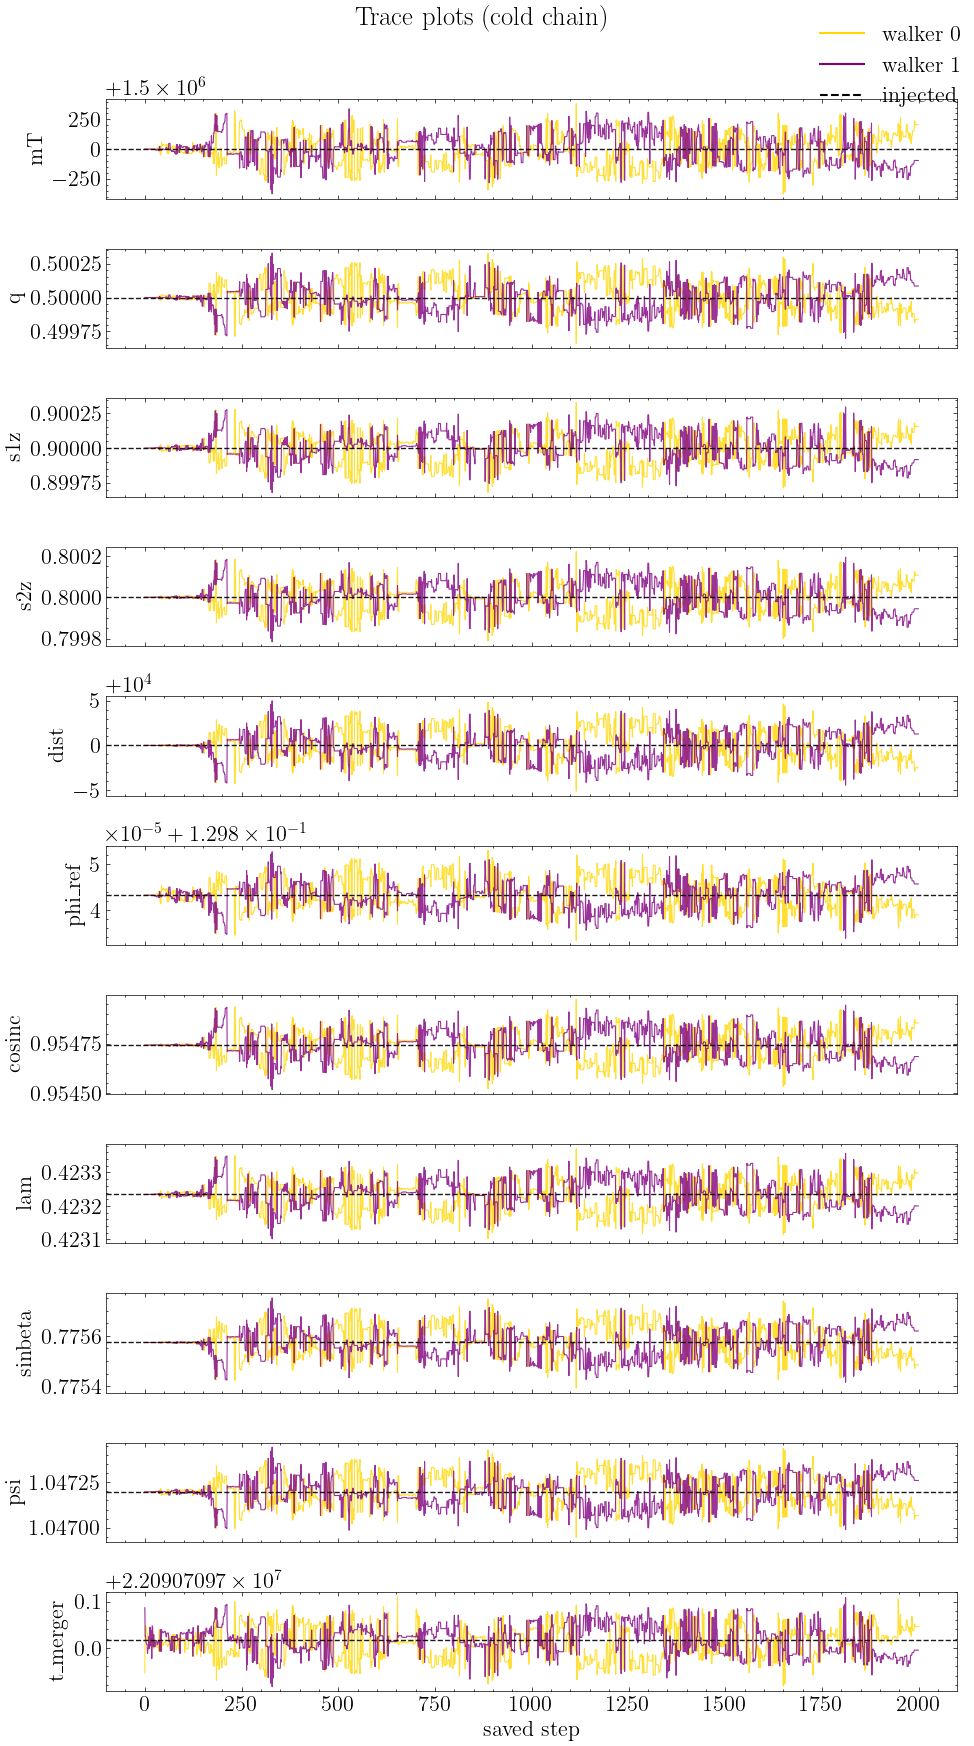

In [5]:
from matplotlib.lines import Line2D

cold = mbh[:, 0, :, 0, :]  # (nsteps_saved, nwalkers, ndim)

WALKER_COLORS = ["gold", "purple"]
TRACE_INJ_COLOR = "black"

fig, axes = plt.subplots(ndim, 1, figsize=(10, 1.6 * ndim), sharex=True)
for i, name in enumerate(PARAM_NAMES):
    ax = axes[i]
    for w in range(nwalkers):
        ax.plot(cold[:, w, i], lw=0.8, alpha=0.8,
                color=WALKER_COLORS[w % len(WALKER_COLORS)])
    ax.axhline(truth[i], ls="--", color=TRACE_INJ_COLOR, lw=1.0, alpha=0.9)
    ax.set_ylabel(name)
axes[-1].set_xlabel("saved step")

legend_handles = [
    Line2D([0], [0], color=WALKER_COLORS[w % len(WALKER_COLORS)], lw=1.5,
           label=f"walker {w}")
    for w in range(nwalkers)
] + [
    Line2D([0], [0], color=TRACE_INJ_COLOR, lw=1.5, ls="--", label="injected"),
]
fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(1.0, 1.0))
fig.suptitle("Trace plots (cold chain)", y=1.0)
fig.tight_layout()

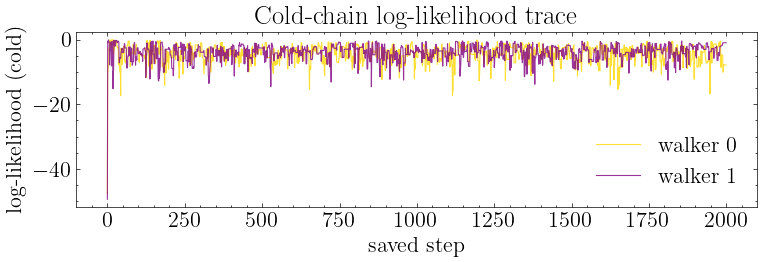

In [6]:
cold_ll = log_like[:, 0, :]  # (nsteps, nwalkers)
fig, ax = plt.subplots(figsize=(8, 3))
for w in range(nwalkers):
    ax.plot(cold_ll[:, w], lw=0.8, alpha=0.8,
            color=WALKER_COLORS[w % len(WALKER_COLORS)],
            label=f"walker {w}")
ax.set_xlabel("saved step")
ax.set_ylabel("log-likelihood (cold)")
ax.legend(loc="best")
ax.set_title("Cold-chain log-likelihood trace")
fig.tight_layout()

## 4. Corner plot

Flattens cold chain across walkers. With this many samples it's not a posterior — it's a scatter plot. Re-run after a longer chain for anything to interpret here.

Optional discard: drop the first `discard` steps as burn-in.

flat samples shape: (4000, 11)


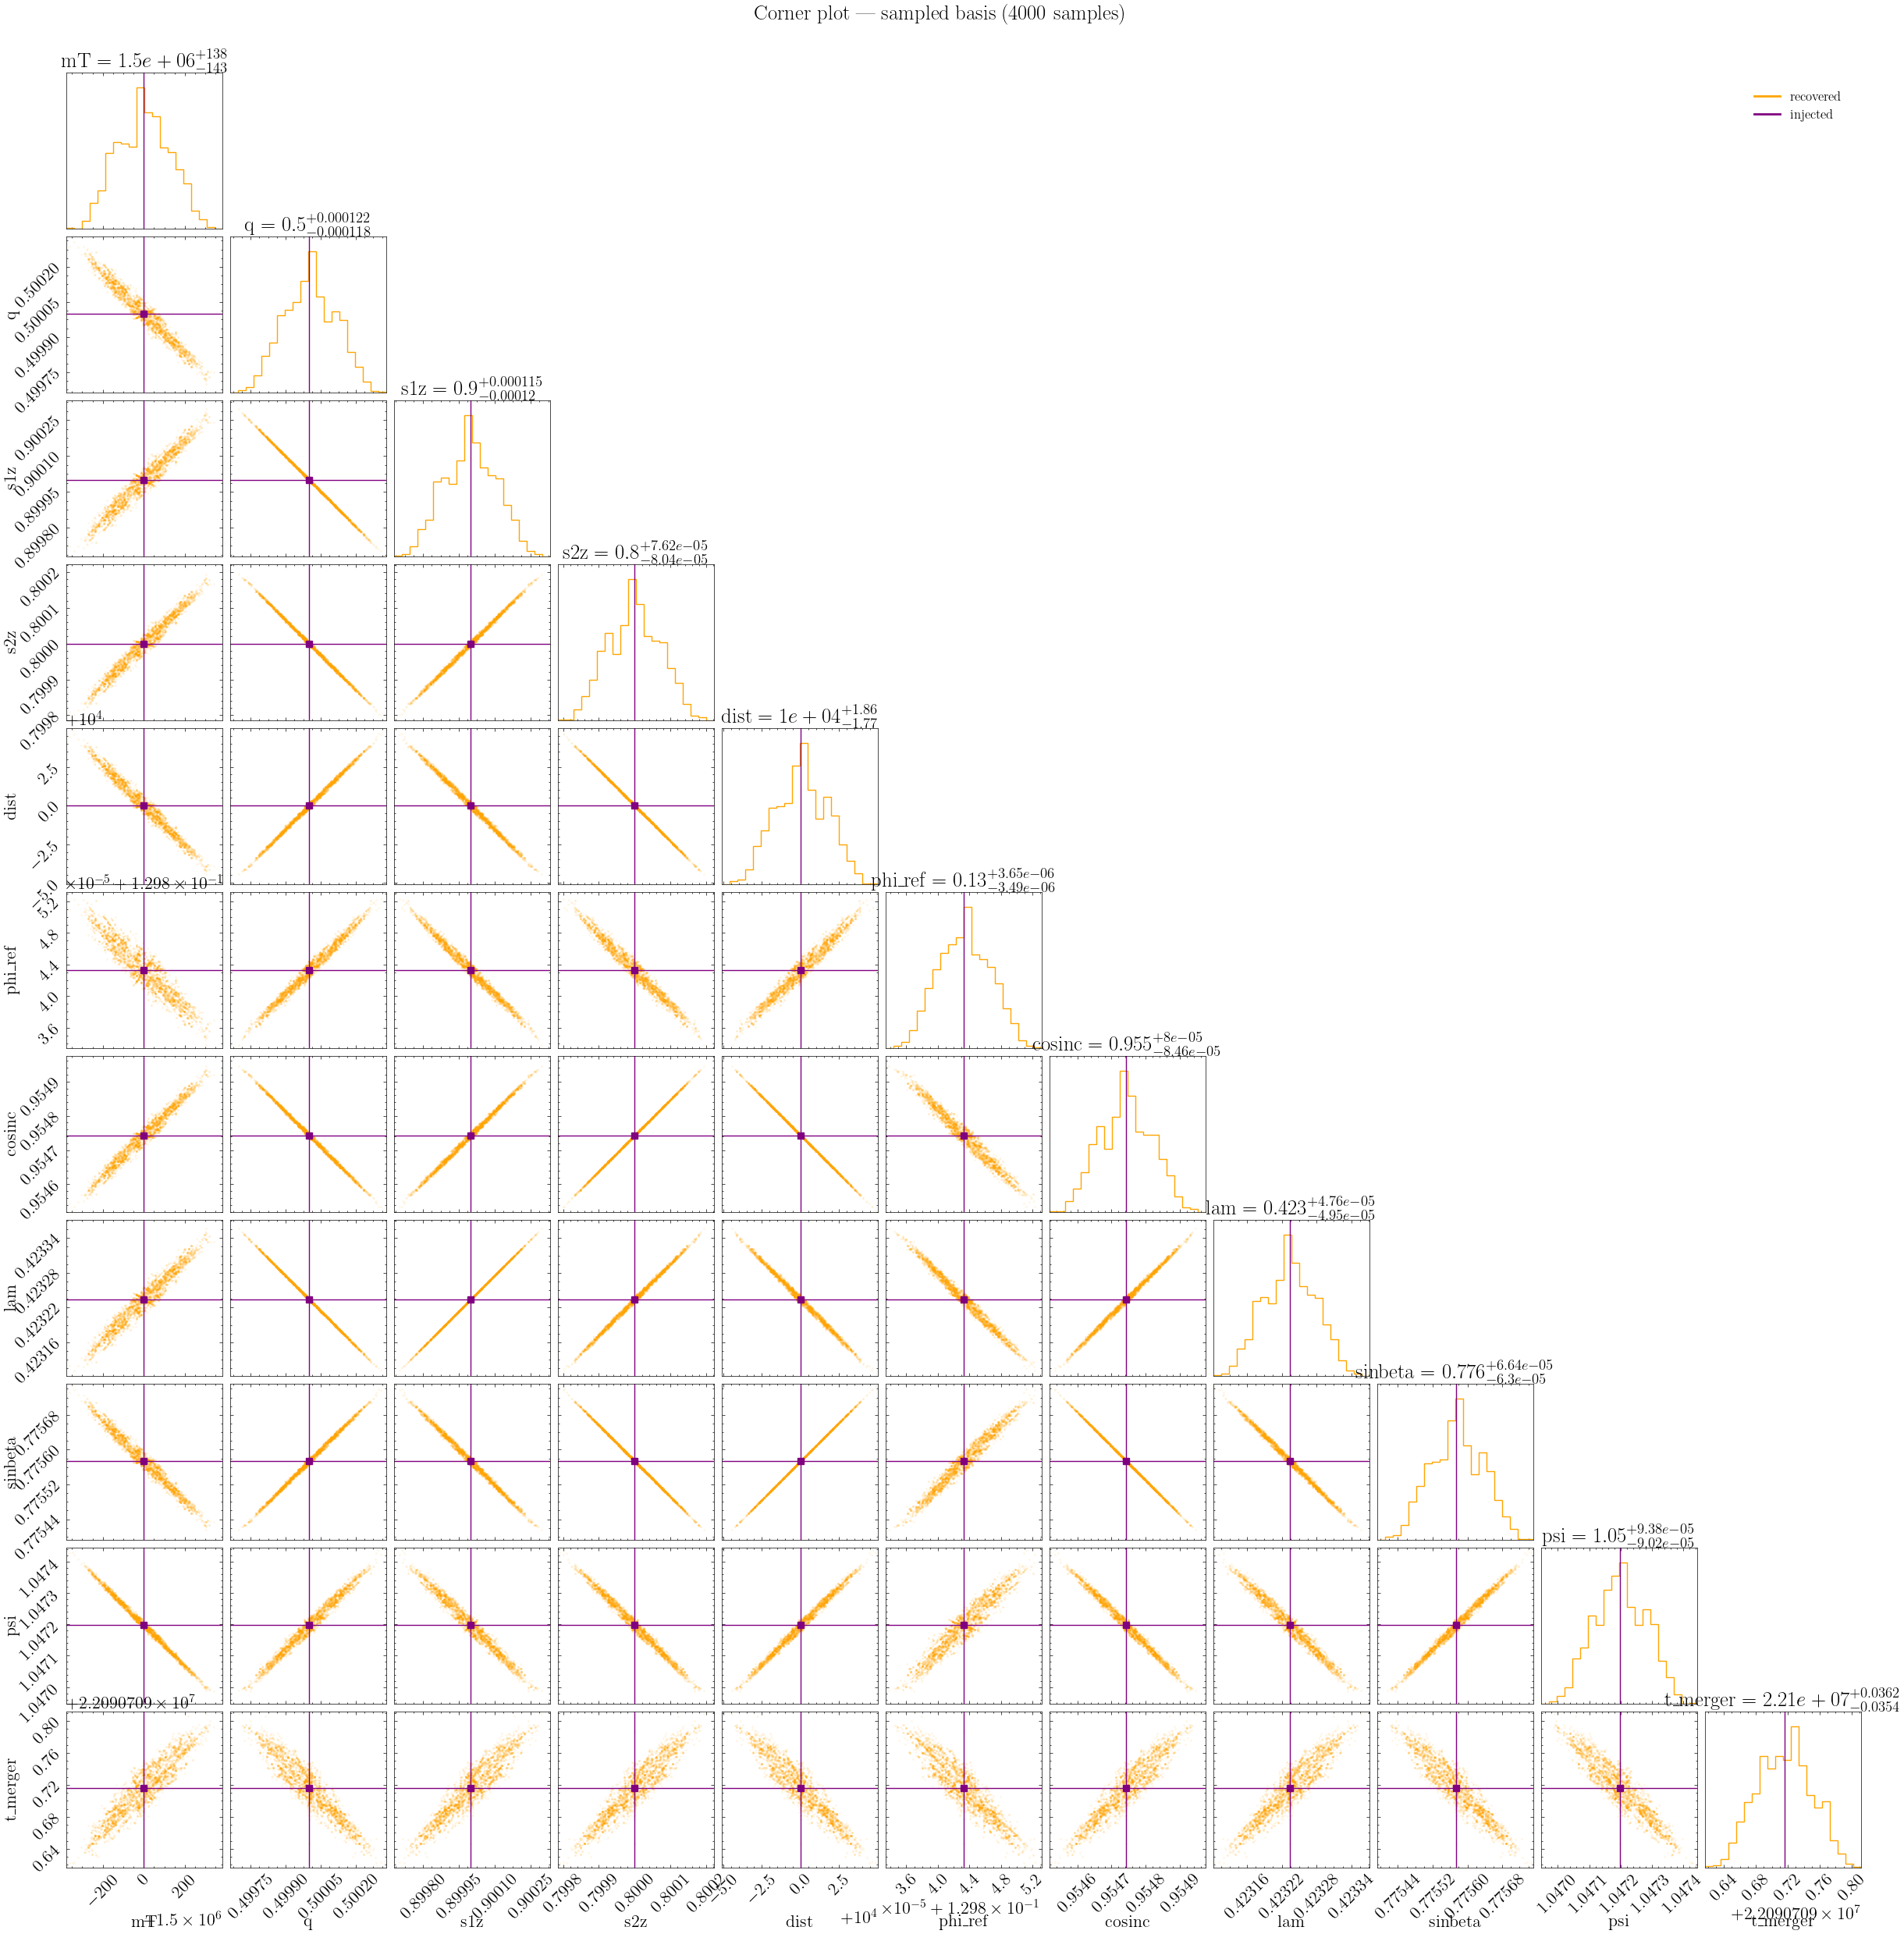

In [7]:
from matplotlib.lines import Line2D

discard = 0
flat = cold[discard:].reshape(-1, ndim)
print("flat samples shape:", flat.shape)

try:
    import corner
    fig = corner.corner(
        flat,
        labels=PARAM_NAMES,
        truths=truth,
        show_titles=True,
        title_fmt=".3g",
        plot_density=False,
        plot_contours=False,    # set True once you have enough samples
        plot_datapoints=True,
        color=REC_COLOR,
        truth_color=INJ_COLOR,
        hist_kwargs=dict(color=REC_COLOR),
    )
    legend_handles = [
        Line2D([0], [0], color=REC_COLOR, lw=2, label="recovered"),
        Line2D([0], [0], color=INJ_COLOR, lw=2, label="injected"),
    ]
    fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=12)
    fig.suptitle(f"Corner plot — sampled basis ({flat.shape[0]} samples)", y=1.02)
except ImportError:
    print("`corner` not installed in this env — `pip install corner`")

## 5. Sampled basis -> physical basis

The sampler walks in `(mT, q, ..., cosinc, sinbeta, ...)`. For interpretation in component masses, inclination, and ecliptic latitude, undo the transforms.

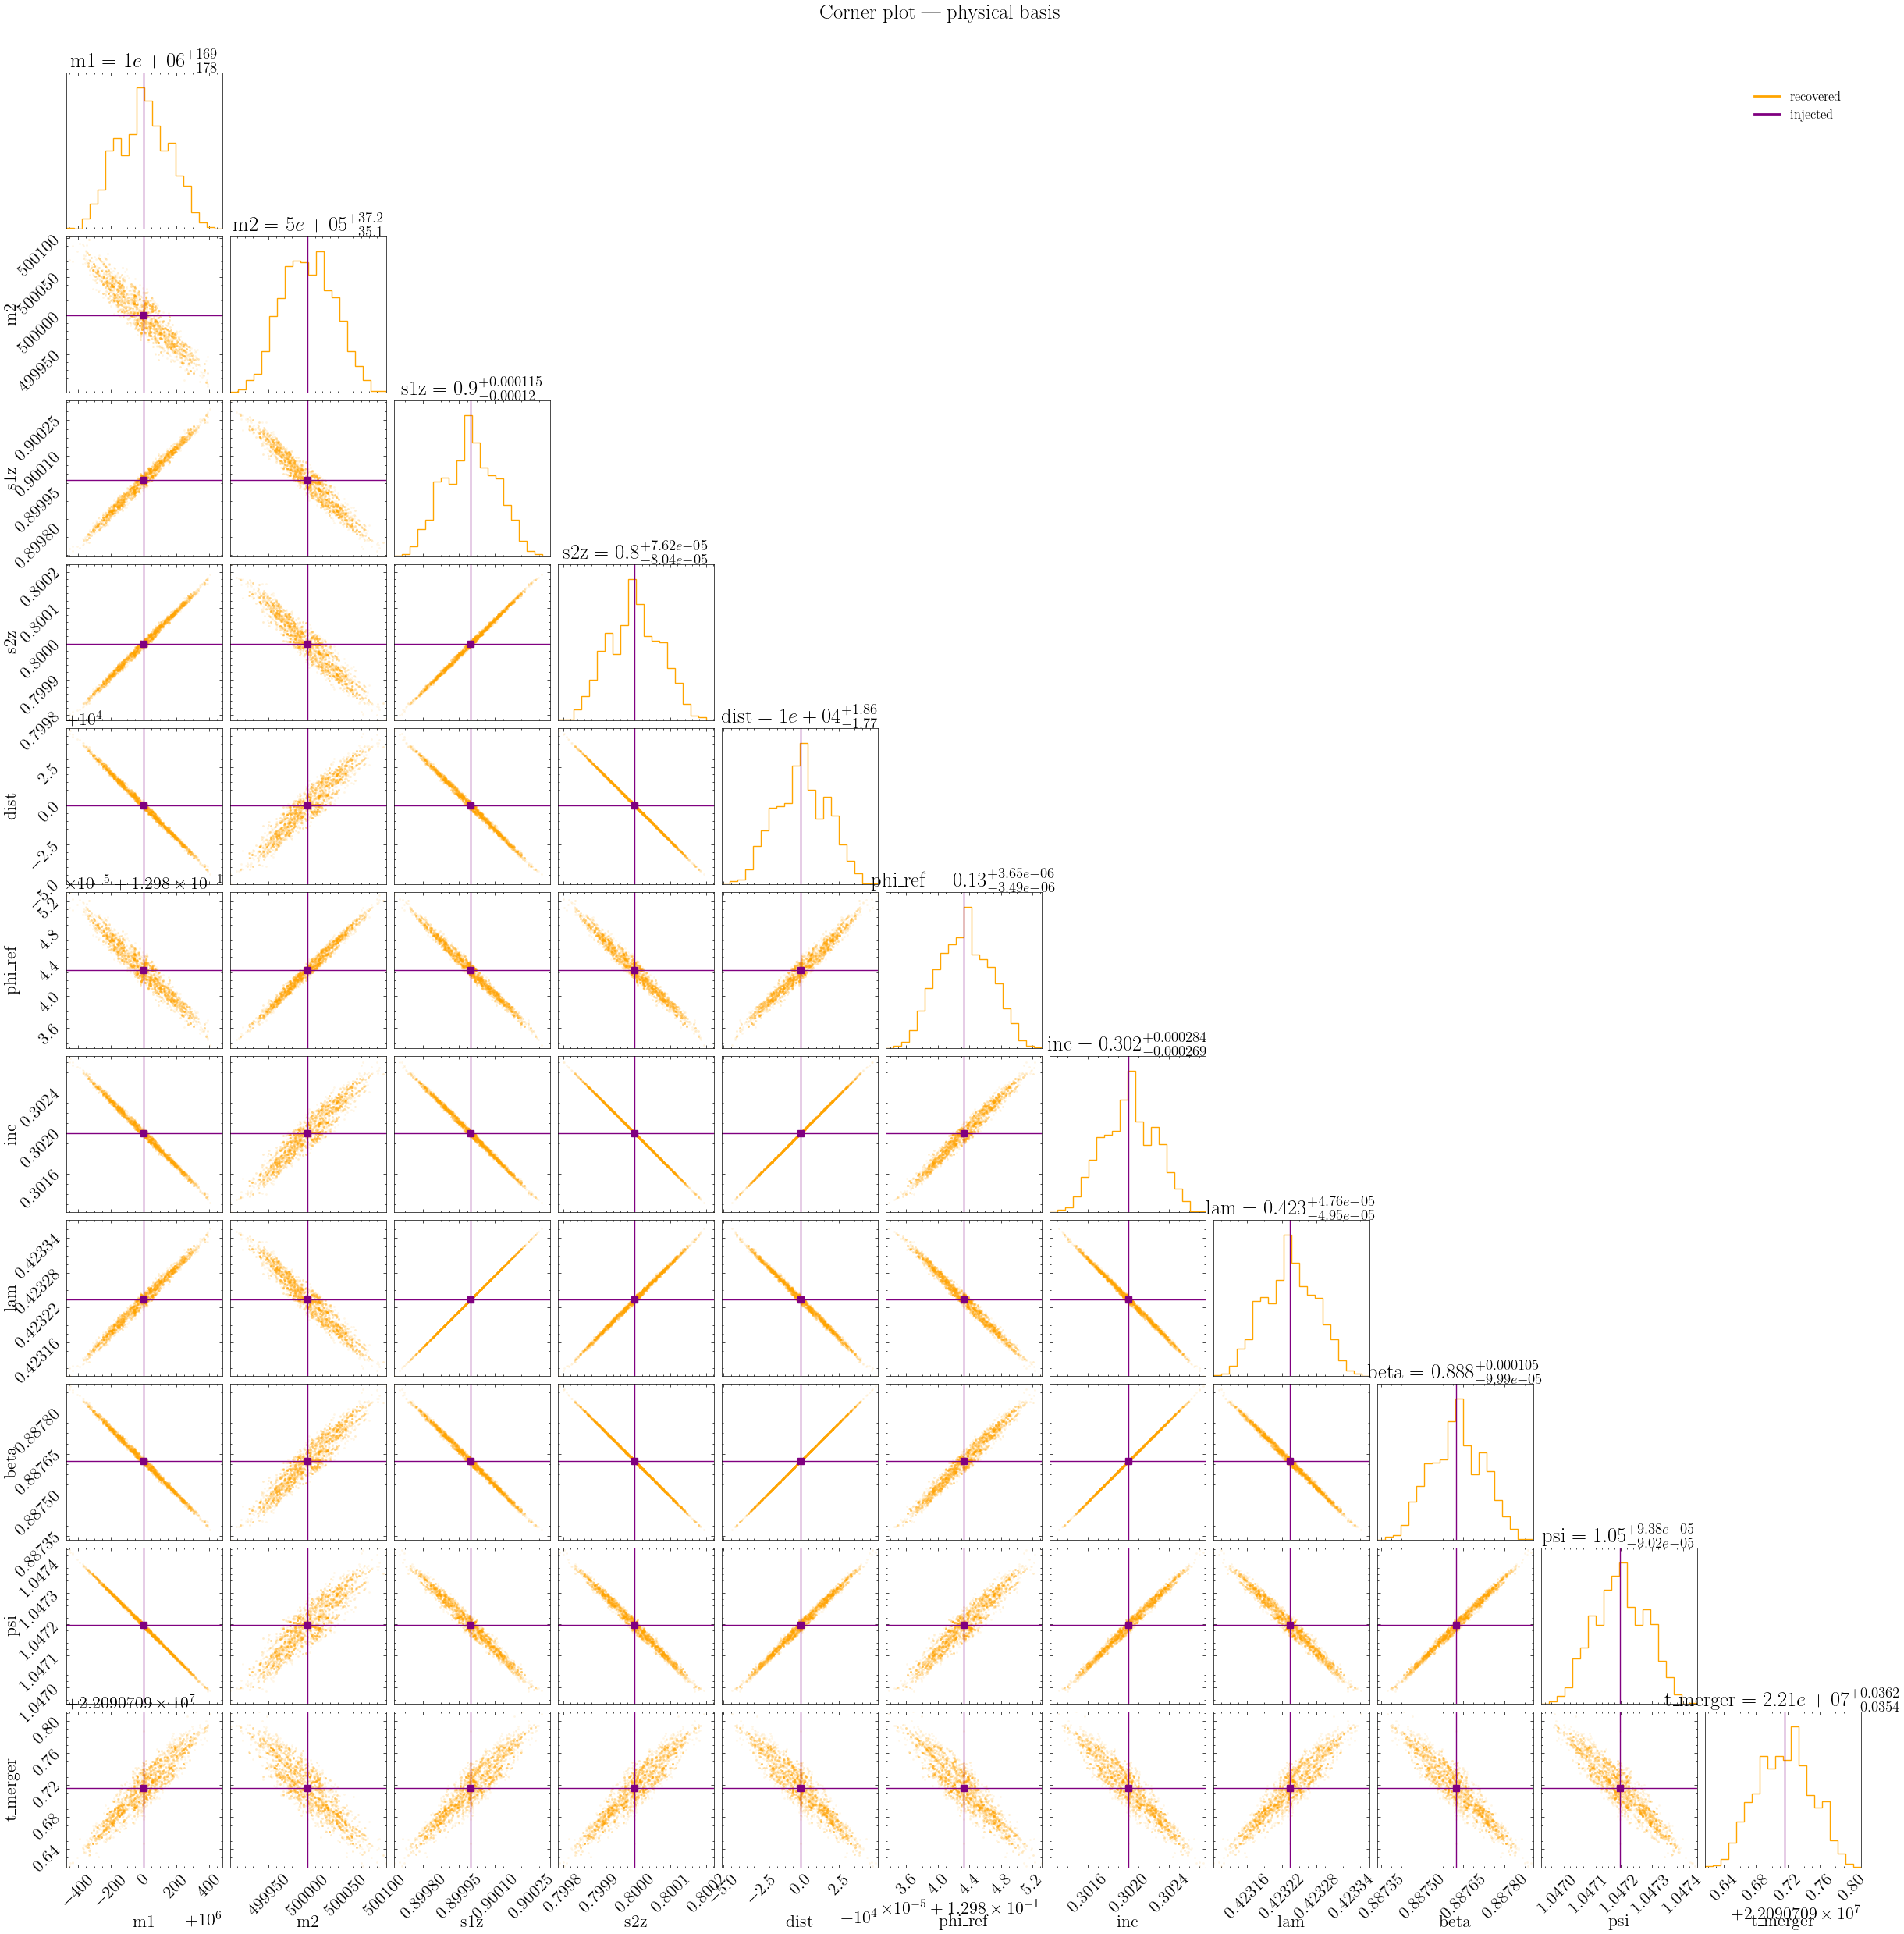

In [8]:
from matplotlib.lines import Line2D

mT_s = flat[:, PARAM_NAMES.index("mT")]
q_s = flat[:, PARAM_NAMES.index("q")]
m1_s = mT_s / (1.0 + q_s)
m2_s = mT_s * q_s / (1.0 + q_s)
inc_s = np.arccos(flat[:, PARAM_NAMES.index("cosinc")])
beta_s = np.arcsin(flat[:, PARAM_NAMES.index("sinbeta")])

physical = np.column_stack([
    m1_s, m2_s,
    flat[:, PARAM_NAMES.index("s1z")],
    flat[:, PARAM_NAMES.index("s2z")],
    flat[:, PARAM_NAMES.index("dist")],
    flat[:, PARAM_NAMES.index("phi_ref")],
    inc_s,
    flat[:, PARAM_NAMES.index("lam")],
    beta_s,
    flat[:, PARAM_NAMES.index("psi")],
    flat[:, PARAM_NAMES.index("t_merger")],
])
PHYSICAL_NAMES = ["m1", "m2", "s1z", "s2z", "dist", "phi_ref",
                  "inc", "lam", "beta", "psi", "t_merger"]
physical_truth = np.array([
    1.0e6, 5.0e5, 0.9, 0.8, 1.0e4, 0.12984324823423,
    0.302001, 0.423234242, 0.88762349812312, np.pi / 3.0,
    INJECTED["t_merger"],
])

try:
    import corner
    fig = corner.corner(
        physical,
        labels=PHYSICAL_NAMES,
        truths=physical_truth,
        show_titles=True,
        title_fmt=".3g",
        plot_density=False,
        plot_contours=False,
        plot_datapoints=True,
        color=REC_COLOR,
        truth_color=INJ_COLOR,
        hist_kwargs=dict(color=REC_COLOR),
    )
    legend_handles = [
        Line2D([0], [0], color=REC_COLOR, lw=2, label="recovered"),
        Line2D([0], [0], color=INJ_COLOR, lw=2, label="injected"),
    ]
    fig.legend(handles=legend_handles, loc="upper right", bbox_to_anchor=(0.98, 0.98), fontsize=12)
    fig.suptitle("Corner plot — physical basis", y=1.02)
except ImportError:
    pass

## 6. Suggestions for the next run

- **Longer chains:** raise `nsteps` in `mbh_test_script_td_wave.py` to a few thousand. With `thin_by=5`, even 5000 steps gives only ~1000 saved samples per walker. The script writes incrementally to `test_mbh_pe.h5` so you can Ctrl-C and resume — the `if os.path.exists(fp)` branch already picks up the last sample.
- **More walkers/temps:** `nwalkers=2` is below the StretchMove rule of thumb (>= 2*ndim, so >=22). Bump it once you trust the pipeline.
- **Autocorrelation:** once you have >50x autocorr-time worth of samples, `backend.get_autocorr_time()` will stop raising and you can thin properly.
- **Sensible burn-in:** look at the log-likelihood trace and discard everything before it plateaus — set `discard` in the corner-plot cell.